## Import

In [1]:
import pandas as pd
from ImpararePackage import dataRequest

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn import tree

import joblib

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

## Download da tabela 'imparare2_dataset_label_full'

In [3]:
query = """
    select 
        pa."caso infeccao",
        --pa."caso infeccao hospitalar",
        --pa."Conjuntivite",
        --pa."Infecção da cavidade oral",
        --pa."Infecção de pele",
        --pa."Meningite",
        --pa.comunitaria,
        --pa.enterocolite,
        --pa.ipcs,
        --pa.isc,
        --pa.pav,
        dtf.*
    from imparare2_dataset_label_full dtf
    inner join new_avaliacao_padrao_ouro pa
        on dtf."registro" = pa.registro 
            and dtf."dia_parsed" = pa.dt_infeccao
"""

df = dataRequest.get_data(queryText= query, chunck= None)
# df.to_feather("arquivo_completo_rodrigo.feather")

### Organização de Variáveis

In [4]:
#só dados_controle e gabaritos foram ajustadas para pegar dados do dataset_full e novo padrão ouro, só para caso infecção por hora.
# Dado controle - quem é e de quando é
dados_controle = ["registro", "dia_parsed"]#, "dthr_internacao", "dthr_alta"]

# Dado texto: 
#dado_categoricos = ["UNIDADE_INTERNACAO", "ESPECIALIDADE_INTERNACAO", "TIPO_INTERNACAO", "CLINICA_INTERNACAO", "SEXO", "TEMP_INCUBADORA_min", "TEMP_INCUBADORA_max", "TEMP_INCUBADORA_count", "TEMP_INCUBADORA_avg", "TEMP_INCUBADORA_stddev", "TEMP_INCUBADORA_delta", "UNIDADE_fim_janela", "UNIDADE_inicio_janela", "agg_hemocultura", "agg_urocultura"]

# Gabaritos
gabaritos = ['caso infeccao'] #, 'caso infeccao hospitalar', 'Conjuntivite', 'Infecção da cavidade oral', 'Infecção de pele', 'Meningite', 'comunitaria', 'enterocolite', 'ipcs', 'isc', 'pav']

# Features
#features_atendimento = ["IDADE", "los_dias", "los_horas"]

#features_cirurgias = ["CIRURGIA_tempo_total", "CIRURGIA_procedimentos_total"]

# Sinais vitais
#features_sinal_vital = ["TECNICO(A) EM ENFERMAGEM_count", "TECNICO(A) EM ENFERMAGEM_avg", "ENFERMEIRO(A)_count", "ENFERMEIRO(A)_avg", "AUXILIAR DE ENFERMAGEM_count", "AUXILIAR DE ENFERMAGEM_avg", "ACADEMICODE ENFERMAGEM_count", "ACADEMICO DE ENFERMAGEM_avg", "MEDICO_count", "MEDICO_avg", "FISIOTERAPEUTA_count", "FISIOTERAPEUTA_avg", "OUTROS_count", "OUTROS_avg", "DIUR_min", "DIUR_max", "DIUR_count", "DIUR_avg", "DIUR_stddev", "DIUR_delta", "FC_min", "FC_max", "FC_count", "FC_avg", "FC_stddev", "FC_delta", "FR_min", "FR_max", "FR_count", "FR_avg", "FR_stddev", "FR_delta", "HGT_min", "HGT_max", "HGT_count", "HGT_avg", "HGT_stddev", "HGT_delta", "OXIMETRIA_min", "OXIMETRIA_max", "OXIMETRIA_count", "OXIMETRIA_avg", "OXIMETRIA_stddev", "OXIMETRIA_delta", "PAD_min", "PAD_max", "PAD_count", "PAD_avg", "PAD_stddev", "PAD_delta", "PAS_min", "PAS_max", "PAS_count", "PAS_avg", "PAS_stddev", "PAS_delta", "TEMP_min", "TEMP_max", "TEMP_count", "TEMP_avg", "TEMP_stddev", "TEMP_delta", "PA_min", "PA_max", "PA_count", "PA_avg", "PA_stddev", "PA_delta", "PAM_min", "PAM_max", "PAM_count", "PAM_avg", "PAM_stddev", "PAM_delta", "O2_min", "O2_max", "O2_count", "O2_avg", "O2_stddev", "O2_delta", "FIO2_min", "FIO2_max", "FIO2_count", "FIO2_avg", "FIO2_stddev", "FIO2_delta", "PEEP_min", "PEEP_max", "PEEP_count", "PEEP_avg", "PEEP_stddev", "PEEP_delta", "SINAIS_VITAIS_registros_total", "FEBRE_indicada"]

# Volumetrico evos e movimentacao
#features_evol = ["UNIDADE_movimento_total", "EVOLUCAO_notas_total", "EVOLUCAO_notas_total_dia"]

# Antibioticos utilizados
#features_atb = ["aciclovir_count", "amoxicilina_sulbactam_count", "cefadroxila_count", "cefalotina_count", "cefotaxima_count", "ceftazidima_count", "ceftazidima_avibactam_count", "ceftalozana_tazobactam_count", "cetoconazol_count", "claritromicina_count", "cloranfenicol_count", "doxiciclina_count", "ertapenem_count", "eritromicina_count", "ganciclovir_count", "ivermectina_count", "micafungina_count", "miconazol_count", "moxifloxacino_count", "mupirocina_count", "neomicina_count", "rifampicina_count", "sulfadiazina_count", "teicoplanina_count", "voriconazol_count", "ciprofloxacino_count", "outro_count", "amicacina_count", "amoxicilina_clavulanato_count", "amoxicilina_count", "ampicilina_count", "azitromicina_count", "penicilinagbenzatina_count", "penicilinagpotassica_count", "cefalexina_count", "cefazolina_count", "cefepima_count", "ceftriaxona_count", "cefuroxima_count", "clindamicina_count", "fluconazol_count", "gentamicina_count", "levofloxacino_count", "linezolida_count", "meropenem_count", "metronidazol_count", "nistatina_count", "oxacilina_count", "piperacilina_tazobactam_count", "ampicilina_sulbactam_count", "sulfametoxazol_trimetoprim_count", "polimixinab_count", "tobramicina_count", "vancomicina_count", "via_topico_count", "via_sng_count", "via_outro_count", "via_ev_count", "via_im_count", "via_vo_count"]

# Dados de exame
# Culturais
#features_culturais = ["qtd_hemocultura_positiva", "qtd_hemocultura_sem_crescimento", "qtd_cultura_positiva", "qtd_cultura_sem_crescimento", "qtd_bacteroscopico_positiva", "qtd_bacteroscopico_negativa", "qtd_urocultura_positiva", "qtd_urocultura_sem_crescimento", "qtd_bacteriologico_positiva", "qtd_bacteriologico_sem_crescimento"]

# Sangue
#features_sangue = ["leuco_min", "leuco_max", "leuco_avg", "rdw_min", "rdw_max", "rdw_avg", "neuto_min", "neuto_max", "neuto_avg"]

# Laudos Imagem
#features_laudos_imagem = ["RAGIOLOGIA_laudos_total"]

# Proporção de termos no texto 
#features_proporcao_texto = ["tosse", "ronco", "cavita", "opac", "infil", "fibrose_cistica", "sec_pur_pulmonar", "secr", "puru", "secr_traq", "o2", "dpoc", "hemoptise", "leucemia", "esplenectomia", "febre", "consol", "linfoma", "acinetobacter", "amarelada", "aspiracao", "broncograma_aereo", "crepitante", "enterobacter", "enterococcus", "hemophylus", "hipertermia", "imunossuprimido", "infeccao", "klebsiella", "legionella", "leucocitose", "leucopenia", "moraxella", "pneumococcus", "pseudomonas", "sibilos", "intubacao", "staphylococcus_aureus", "sepse_pulmonar", "sepse_respiratoria", "sepse_urinaria", "padrao_ventilatorio", "insuficiencia_ventilatoria", "esforco_ventilatorio", "lavado_broncoalveolar", "derrame_pleural", "escherichia_coli", "choque_septico", "dor_pleuritica", "dor_ventilatorio_dependente", "ventilacao_mecanica", "iot", 
                            # "pav_1",
                            #"endoftalmite", "eritema", "hiperemia", "mediastinite", "staphylococcus_coagulase_negativo", "supuracao", "rubor", "mal_estar", "abscesso", "calor", "dreno", "edema", "endocardite", "antibiotico", "bacteriologico", "deiscencia", "resistente", "taquicardia", "cateter", "cateter_arterial", "cateter_urinario", "cvc", "cateter_venoso_periferico", "clorose", "instabilidade", "oliguria", "hipotensao", "anuria", "bacteremia", "bacteriuria", "disuria", "leucocituria", "nitrito", "svd", "tsa", "choque", "staphylococcus", "e_coli", "colecao", "tremor", "calafrio", "pos_operatorio", "dor_suprapubica", "foco_urinario", "colite_pseudomembranosa", "yersinia", "vomito", "shigella", "salmonela", "nausea", "giardia", "dor_cabeca", "dor_abdominal", "diarreia", "clostridium", "campylobacter", "urgencia_urinaria", "urgencia_miccional", "sondagem_alivio", "sondagem_vesical", "urocultura", "piuria", "albumina", "press_parc_co2", "bicarbonato", "calcio", "creatinina", "glicose", "hemoglobina", "plaquetas", "potassio", "sodio", "bilirrubina", "cardiomegalia", "lesao_pulmonar", "pneumonia", "atelectasia", "pneumotorax", "fratura", "freq_respiratoria", "freq_cardiaca", "pressao_sanguinea", "saturacao_sangue", "hemocultura", "temperatura", "ph_sangue", "propionibacterium", "cryptococcus", "pneumocystis", "histoplasma", "paracoccidioides", "bacteroides", "candida", "fusobacterium", "peptostreptococcus", "sibilancia", "hipotermia", "apneia", "bradicardia", "streptococcus_viridans", "consciencia", "hcm", "hgm", "corynebacterium", "bacillus", "aerococcus", "coccidioides", "veillonella", "covid", "peep", "fio2", "spo2", "avc", "sne", "desnutricao", "sedacao", "vsg", "fosfatase_alcalina", "ldh", "cetamina", "propofol", "clorpromazina", "fentanil", "pancuronio", "noradrenalina", "diazepan", "lorazepan", "flumazenil", "clonidina", "npt", "cateter_monolumen", "cateter_duplolumen", "cateter_triplolumen", "portocath", "cateter_hickmann", "shilley", "obesidade", "diabetes", "neutropenia", "tabagismo"]

# contagem de termos em texto
#features_contagem_texto = ["tosse_pos_count", "ronco_pos_count", "cavita_pos_count", "opac_pos_count", "infil_pos_count", "fibrose_cistica_pos_count", "sec_pur_pulmonar_pos_count", "secr_pos_count", "puru_pos_count", "secr_traq_pos_count", "o2_pos_count", "dpoc_pos_count", "hemoptise_pos_count", "leucemia_pos_count", "esplenectomia_pos_count", "febre_pos_count", "consol_pos_count", "linfoma_pos_count", "acinetobacter_pos_count", "amarelada_pos_count", "aspiracao_pos_count", "broncograma_aereo_pos_count", "crepitante_pos_count", "enterobacter_pos_count", "enterococcus_pos_count", "hemophylus_pos_count", "hipertermia_pos_count", "imunossuprimido_pos_count", "infeccao_pos_count", "klebsiella_pos_count", "legionella_pos_count", "leucocitose_pos_count", "leucopenia_pos_count", "moraxella_pos_count", "pneumococcus_pos_count", "pseudomonas_pos_count", "sibilos_pos_count", "intubacao_pos_count", "staphylococcus_aureus_pos_count", "sepse_pulmonar_pos_count", "sepse_respiratoria_pos_count", "sepse_urinaria_pos_count", "padrao_ventilatorio_pos_count", "insuficiencia_ventilatoria_pos_count", "esforco_ventilatorio_pos_count", "lavado_broncoalveolar_pos_count", "derrame_pleural_pos_count", "escherichia_coli_pos_count", "choque_septico_pos_count", "dor_pleuritica_pos_count", "dor_ventilatorio_dependente_pos_count", "ventilacao_mecanica_pos_count", "iot_pos_count", "pav_pos_count", "endoftalmite_pos_count", "eritema_pos_count", "hiperemia_pos_count", "mediastinite_pos_count", "staphylococcus_coagulase_negativo_pos_count", "supuracao_pos_count", "rubor_pos_count", "mal_estar_pos_count", "abscesso_pos_count", "calor_pos_count", "dreno_pos_count", "edema_pos_count", "endocardite_pos_count", "antibiotico_pos_count", "bacteriologico_pos_count", "deiscencia_pos_count", "resistente_pos_count", "taquicardia_pos_count", "cateter_pos_count", "cateter_arterial_pos_count", "cateter_urinario_pos_count", "cvc_pos_count", "cateter_venoso_periferico_pos_count", "clorose_pos_count", "instabilidade_pos_count", "oliguria_pos_count", "hipotensao_pos_count", "anuria_pos_count", "bacteremia_pos_count", "bacteriuria_pos_count", "disuria_pos_count", "leucocituria_pos_count", "nitrito_pos_count", "svd_pos_count", "tsa_pos_count", "choque_pos_count", "staphylococcus_pos_count", "e_coli_pos_count", "colecao_pos_count", "tremor_pos_count", "calafrio_pos_count", "pos_operatorio_pos_count", "dor_suprapubica_pos_count", "foco_urinario_pos_count", "colite_pseudomembranosa_pos_count", "yersinia_pos_count", "vomito_pos_count", "shigella_pos_count", "salmonela_pos_count", "nausea_pos_count", "giardia_pos_count", "dor_cabeca_pos_count", "dor_abdominal_pos_count", "diarreia_pos_count", "clostridium_pos_count", "campylobacter_pos_count", "urgencia_urinaria_pos_count", "urgencia_miccional_pos_count", "sondagem_alivio_pos_count", "sondagem_vesical_pos_count", "urocultura_pos_count", "piuria_pos_count", "albumina_pos_count", "press_parc_co2_pos_count", "bicarbonato_pos_count", "calcio_pos_count", "creatinina_pos_count", "glicose_pos_count", "hemoglobina_pos_count", "plaquetas_pos_count", "potassio_pos_count", "sodio_pos_count", "bilirrubina_pos_count", "cardiomegalia_pos_count", "lesao_pulmonar_pos_count", "pneumonia_pos_count", "atelectasia_pos_count", "pneumotorax_pos_count", "fratura_pos_count", "freq_respiratoria_pos_count", "freq_cardiaca_pos_count", "pressao_sanguinea_pos_count", "saturacao_sangue_pos_count", "hemocultura_pos_count", "temperatura_pos_count", "ph_sangue_pos_count", "propionibacterium_pos_count", "cryptococcus_pos_count", "pneumocystis_pos_count", "histoplasma_pos_count", "paracoccidioides_pos_count", "bacteroides_pos_count", "candida_pos_count", "fusobacterium_pos_count", "peptostreptococcus_pos_count", "sibilancia_pos_count", "hipotermia_pos_count", "apneia_pos_count", "bradicardia_pos_count", "streptococcus_viridans_pos_count", "consciencia_pos_count", "hcm_pos_count", "hgm_pos_count", "corynebacterium_pos_count", "bacillus_pos_count", "aerococcus_pos_count", "coccidioides_pos_count", "veillonella_pos_count", "covid_pos_count", "peep_pos_count", "fio2_pos_count", "spo2_pos_count", "avc_pos_count", "sne_pos_count", "desnutricao_pos_count", "sedacao_pos_count", "vsg_pos_count", "fosfatase_alcalina_pos_count", "ldh_pos_count", "cetamina_pos_count", "propofol_pos_count", "clorpromazina_pos_count", "fentanil_pos_count", "pancuronio_pos_count", "noradrenalina_pos_count", "diazepan_pos_count", "lorazepan_pos_count", "flumazenil_pos_count", "clonidina_pos_count", "npt_pos_count", "cateter_monolumen_pos_count", "cateter_duplolumen_pos_count", "cateter_triplolumen_pos_count", "portocath_pos_count", "cateter_hickmann_pos_count", "shilley_pos_count", "obesidade_pos_count", "diabetes_pos_count", "neutropenia_pos_count", "tabagismo_pos_count"]

# Data Exploring

## Organização de variaveis

### (Gabaritos) + texto sem contagem + exames

In [ ]:
#df_texto_gabarito = df[gabaritos+features_proporcao_texto+features_culturais+features_sangue+features_laudos_imagem]
#df_texto_gabarito.head()

,caso infeccao,caso infeccao hospitalar,Conjuntivite,Infecção da cavidade oral,Infecção de pele,Meningite,comunitaria,enterocolite,ipcs,isc,...,leuco_min,leuco_max,leuco_avg,rdw_min,rdw_max,rdw_avg,neuto_min,neuto_max,neuto_avg,RAGIOLOGIA_laudos_total
0,False,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000
1,False,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000
2,False,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000
3,True,False,False,False,False,False,True,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
4,False,False,False,False,False,False,False,False,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000


## Variáveis treino e teste

### (Gabaritos) + Texto sem contagem e exames

In [19]:
X_texto = df.drop(columns= ['caso infeccao', "registro", "dia_parsed"])

y_texto = df['caso infeccao']
X_texto_train, X_texto_test, y_texto_train, y_texto_test = train_test_split(X_texto, y_texto, test_size=0.33, random_state=42, stratify= y_texto)
len(X_texto_train), len(X_texto_test), len(y_texto_train), len(y_texto_test)

(21409, 10546, 21409, 10546)

In [20]:
display(X_texto.dtypes)

idade                                   int64
los_dias                                int64
los_horas                               int64
CIRURGIA_tempo_total                    int64
CIRURGIA_procedimentos_total            int64
                                       ...   
asp_bilioso_passado_sent_pos_count      int64
letargia_passado                      float64
letargia_passado_sent_pos_count         int64
int_glicose_passado                   float64
int_glicose_passado_sent_pos_count      int64
Length: 1492, dtype: object

### Split dataset - texto sem contagem e exames

In [25]:
# X = df.drop(columns= ["avc","TEMP_INCUBADORA_min", "TEMP_INCUBADORA_max", "TEMP_INCUBADORA_count", "TEMP_INCUBADORA_avg", "TEMP_INCUBADORA_stddev", "TEMP_INCUBADORA_delta",'REGISTRO', 'los_horas', 'caso_infeccao', 'pnm', 'isc', 'itu', 'pav', 'ipcs', 'traqueobronquite', 'DIA_parsed', 'SEXO', 'UNIDADE_INTERNACAO', 'UNIDADE_INTERNACAO', 'ESPECIALIDADE_INTERNACAO', 'TIPO_INTERNACAO',	'CLINICA_INTERNACAO', 'dthr_internacao', 'dthr_alta', 'UNIDADE_fim_janela', 'UNIDADE_inicio_janela', 'agg_hemocultura', 'agg_urocultura'])
# y = df['caso_infeccao']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify= y)

### DT - From best estimator params

In [21]:
model = DecisionTreeClassifier(
    criterion='gini', 
    splitter='random', 
    random_state= 20, 
    min_samples_leaf= 2,
    min_samples_split= 3,
    max_features= None,
    max_depth= 18,
    class_weight= {0: 1, 1: 20}
)

model.fit(X_texto_train, y_texto_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'random'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",18
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",20
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [22]:
y_train_pred = model.predict(X_texto_train)
acc = accuracy_score(y_texto_train, y_train_pred)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_texto_train, y_train_pred)
print(f"Confusion Matrix treino: \n{cm}\n")
report = classification_report(y_texto_train, y_train_pred)
print(report)

print("\n=========================================================\n")
# Validando test
y_pred = model.predict(X_texto_test)
    
acc = accuracy_score(y_texto_test, y_pred)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_texto_test, y_pred)
print(f"Confusion Matrix teste: \n{cm}")
report = classification_report(y_texto_test, y_pred)
print(report)

Accurácia: 0.9907048437572983
Confusion Matrix treino: 
[[20856   199]
 [    0   354]]

              precision    recall  f1-score   support

       False       1.00      0.99      1.00     21055
        True       0.64      1.00      0.78       354

    accuracy                           0.99     21409
   macro avg       0.82      1.00      0.89     21409
weighted avg       0.99      0.99      0.99     21409



Accurácia: 0.9833112080409634
Confusion Matrix teste: 
[[10234   137]
 [   39   136]]
              precision    recall  f1-score   support

       False       1.00      0.99      0.99     10371
        True       0.50      0.78      0.61       175

    accuracy                           0.98     10546
   macro avg       0.75      0.88      0.80     10546
weighted avg       0.99      0.98      0.99     10546



### Analisando importância de parâmetros - texto

In [23]:
pd.options.display.float_format = '{:.4f}'.format
importances = pd.Series(model.feature_importances_, index=X_texto_test.columns)

# Ordena em ordem decrescente
importances = importances.sort_values(ascending=False)
print(importances)

importances = importances.to_dict()
importances['model'] = 'random_forest'

via_ev_count                              0.5826
secr_passado_sent_pos_count               0.1206
tobramicina_count                         0.0804
qtd_cultura_positiva_hoje                 0.0426
qtd_cultura_positiva_passado              0.0392
                                           ...  
legionella_futuro_sent_pos_count          0.0000
ph_sangue_futuro                          0.0000
ph_sangue_futuro_sent_pos_count           0.0000
paracoccidioides_futuro_sent_pos_count    0.0000
PAM_delta                                -0.0000
Length: 1492, dtype: float64


In [24]:
text_tree = tree.export_text(model, feature_names=X_texto.columns)
print(text_tree)

|--- via_ev_count <= 1.95
|   |--- secr_passado_sent_pos_count <= 3.88
|   |   |--- tobramicina_count <= 0.67
|   |   |   |--- qtd_cultura_positiva_passado <= 0.72
|   |   |   |   |--- nistatina_count <= 3.25
|   |   |   |   |   |--- qtd_cultura_positiva_hoje <= 1.38
|   |   |   |   |   |   |--- qtd_cultura_positiva_hoje <= 0.96
|   |   |   |   |   |   |   |--- sne_hoje <= 0.44
|   |   |   |   |   |   |   |   |--- neutropenia_passado_sent_pos_count <= 1.66
|   |   |   |   |   |   |   |   |   |--- convulsao_futuro_sent_pos_count <= 5.82
|   |   |   |   |   |   |   |   |   |   |--- ldh_futuro_sent_pos_count <= 1.80
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |   |   |   |   |   |   |   |--- ldh_futuro_sent_pos_count >  1.80
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- convulsao_futuro_sent_pos_count >  5.82
|   |   |   |   |   |   |   |   |   |   |--- sodio_futuro_sent_po

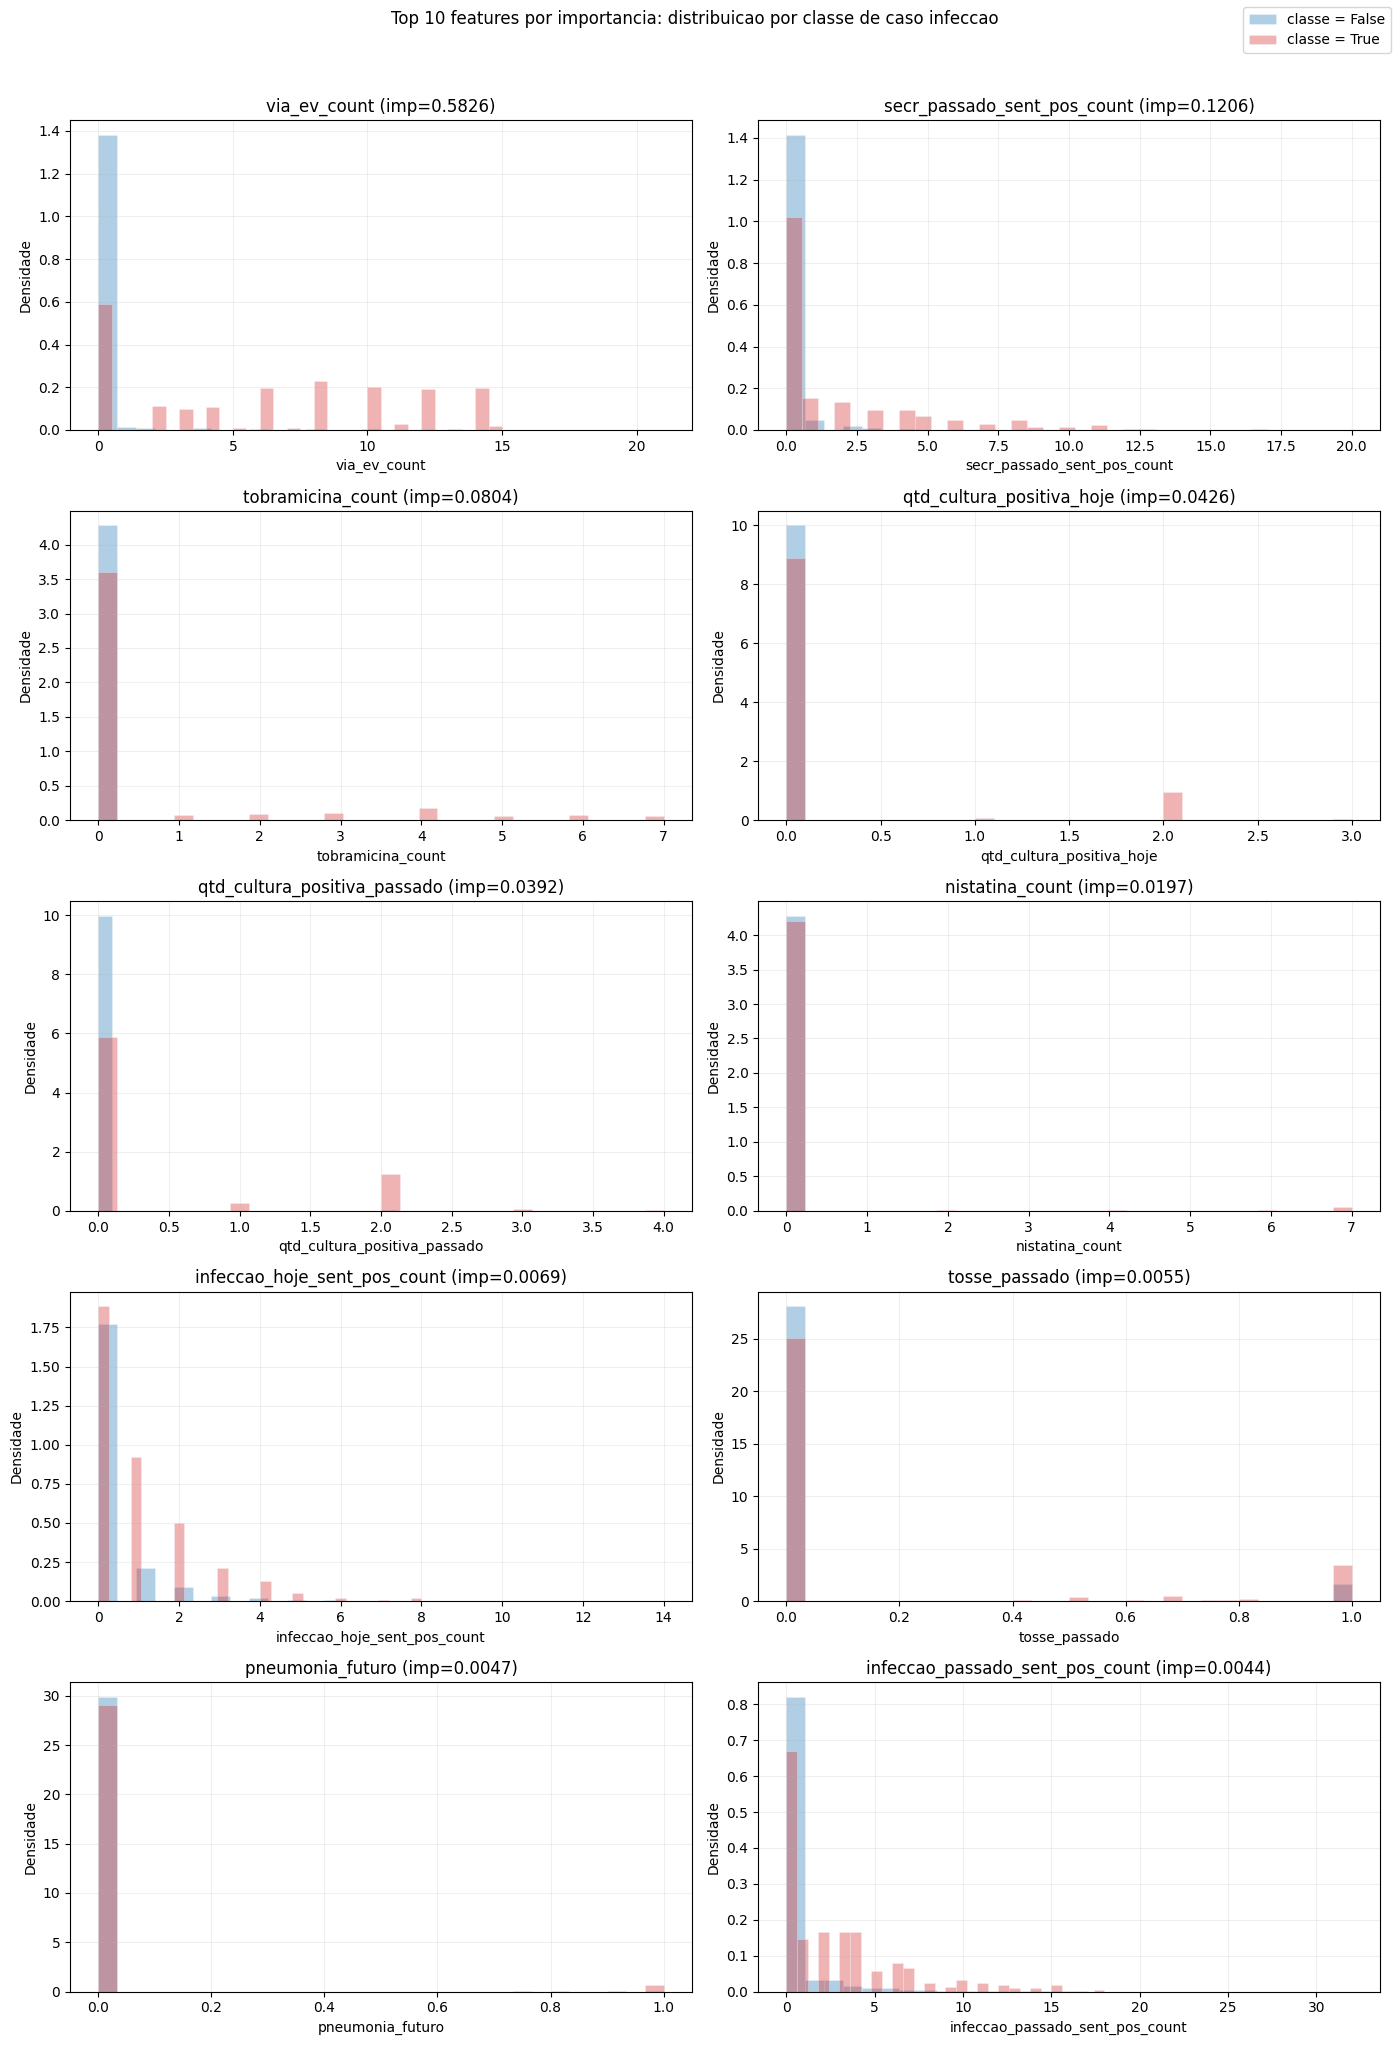

Top 10 features: ['via_ev_count', 'secr_passado_sent_pos_count', 'tobramicina_count', 'qtd_cultura_positiva_hoje', 'qtd_cultura_positiva_passado', 'nistatina_count', 'infeccao_hoje_sent_pos_count', 'tosse_passado', 'pneumonia_futuro', 'infeccao_passado_sent_pos_count']


In [29]:
# Distribuicoes das top 10 features por importancia (overlay por classe)
importance_series = pd.Series(model.feature_importances_, index=X_texto_train.columns).sort_values(ascending=False)
top10_features = importance_series.head(10).index.tolist()

target_col = "caso infeccao"
plot_base = X_texto_train[top10_features].copy()
plot_base[target_col] = y_texto_train
plot_base[target_col] = plot_base[target_col].astype(str)
classes = sorted(plot_base[target_col].dropna().unique())
colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]

n_cols = 2
n_rows = (len(top10_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for idx, feature in enumerate(top10_features):
    ax = axes[idx]
    feature_df = plot_base[[feature, target_col]].dropna()

    for i, classe in enumerate(classes):
        serie = feature_df.loc[feature_df[target_col] == classe, feature]
        ax.hist(
            serie,
            bins=30,
            alpha=0.35,
            density=True,
            label=f"classe = {classe}",
            color=colors[i % len(colors)],
            edgecolor="white",
            linewidth=0.5,
        )

    ax.set_title(f"{feature} (imp={importance_series.loc[feature]:.4f})")
    ax.set_xlabel(feature)
    ax.set_ylabel("Densidade")
    ax.grid(alpha=0.2)

# Remove eixos vazios (caso existam)
for j in range(len(top10_features), len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Top 10 features por importancia: distribuicao por classe de caso infeccao", y=1.02)
plt.tight_layout()
plt.show()

print("Top 10 features:", top10_features)

In [30]:
df_texto_gabarito = df.to_feather("dataset_gabarito_evolucoes_exames_Rodrigo")

ValueError: Duplicate column names found: ['caso infeccao', 'caso infeccao hospitalar', 'Conjuntivite', 'Infecção da cavidade oral', 'Infecção de pele', 'Meningite', 'comunitaria', 'enterocolite', 'ipcs', 'isc', 'pav', 'REGISTRO', 'DIA_parsed', 'IDADE', 'UNIDADE_INTERNACAO', 'ESPECIALIDADE_INTERNACAO', 'TIPO_INTERNACAO', 'CLINICA_INTERNACAO', 'dthr_internacao', 'dthr_alta', 'los_dias', 'los_horas', 'CIRURGIA_tempo_total', 'CIRURGIA_procedimentos_total', 'TECNICO(A) EM ENFERMAGEM_count', 'TECNICO(A) EM ENFERMAGEM_avg', 'ENFERMEIRO(A)_count', 'ENFERMEIRO(A)_avg', 'AUXILIAR DE ENFERMAGEM_count', 'AUXILIAR DE ENFERMAGEM_avg', 'ACADEMICODE ENFERMAGEM_count', 'ACADEMICO DE ENFERMAGEM_avg', 'MEDICO_count', 'MEDICO_avg', 'FISIOTERAPEUTA_count', 'FISIOTERAPEUTA_avg', 'OUTROS_count', 'OUTROS_avg', 'DIUR_min', 'DIUR_max', 'DIUR_count', 'DIUR_avg', 'DIUR_stddev', 'DIUR_delta', 'FC_min', 'FC_max', 'FC_ALTERADA', 'FC_ALTA', 'FC_BAIXA', 'FC_count', 'FC_avg', 'FC_stddev', 'FC_delta', 'FR_min', 'FR_max', 'FR_ALTERADA', 'FR_count', 'FR_avg', 'FR_stddev', 'FR_delta', 'HGT_min', 'HGT_max', 'HGT_ALTERADO', 'HGT_count', 'HGT_avg', 'HGT_stddev', 'HGT_delta', 'OXIMETRIA_min', 'OXIMETRIA_max', 'OXIMETRIA_count', 'OXIMETRIA_avg', 'OXIMETRIA_stddev', 'OXIMETRIA_delta', 'PAD_min', 'PAD_max', 'PAD_count', 'PAD_avg', 'PAD_stddev', 'PAD_delta', 'PAS_min', 'PAS_max', 'PAS_count', 'PAS_avg', 'PAS_stddev', 'PAS_delta', 'TEMP_min', 'TEMP_max', 'TEMP_ALTERADA', 'TEMP_ALTA', 'TEMP_BAIXA', 'TEMP_count', 'TEMP_avg', 'TEMP_stddev', 'TEMP_delta', 'PA_min', 'PA_max', 'PA_count', 'PA_avg', 'PA_stddev', 'PA_delta', 'PAM_min', 'PAM_max', 'PAM_count', 'PAM_avg', 'PAM_stddev', 'PAM_delta', 'O2_min', 'O2_max', 'O2_count', 'O2_avg', 'O2_stddev', 'O2_delta', 'FIO2_min', 'FIO2_max', 'FIO2_count', 'FIO2_avg', 'FIO2_stddev', 'FIO2_delta', 'PEEP_min', 'PEEP_max', 'PEEP_count', 'PEEP_avg', 'PEEP_stddev', 'PEEP_delta', 'SINAIS_VITAIS_registros_total', 'UNIDADE_fim_janela', 'UNIDADE_inicio_janela', 'UNIDADE_movimento_total', 'EVOLUCAO_notas_total', 'EVOLUCAO_notas_total_dia', 'aciclovir_count', 'amoxicilina_sulbactam_count', 'cefadroxila_count', 'cefalotina_count', 'cefotaxima_count', 'ceftazidima_count', 'ceftazidima_avibactam_count', 'ceftalozana_tazobactam_count', 'cetoconazol_count', 'claritromicina_count', 'cloranfenicol_count', 'doxiciclina_count', 'ertapenem_count', 'eritromicina_count', 'ganciclovir_count', 'ivermectina_count', 'micafungina_count', 'miconazol_count', 'moxifloxacino_count', 'mupirocina_count', 'neomicina_count', 'rifampicina_count', 'sulfadiazina_count', 'teicoplanina_count', 'voriconazol_count', 'ciprofloxacino_count', 'outro_count', 'amicacina_count', 'amoxicilina_clavulanato_count', 'amoxicilina_count', 'ampicilina_count', 'azitromicina_count', 'penicilinagbenzatina_count', 'penicilinagpotassica_count', 'cefalexina_count', 'cefazolina_count', 'cefepima_count', 'ceftriaxona_count', 'cefuroxima_count', 'clindamicina_count', 'fluconazol_count', 'gentamicina_count', 'levofloxacino_count', 'linezolida_count', 'meropenem_count', 'metronidazol_count', 'nistatina_count', 'oxacilina_count', 'piperacilina_tazobactam_count', 'ampicilina_sulbactam_count', 'sulfametoxazol_trimetoprim_count', 'polimixinab_count', 'tobramicina_count', 'vancomicina_count', 'via_topico_count', 'via_sng_count', 'via_outro_count', 'via_ev_count', 'via_im_count', 'via_vo_count', 'agg_hemocultura', 'qtd_hemocultura_positiva', 'qtd_hemocultura_sem_crescimento', 'qtd_cultura_positiva', 'qtd_cultura_sem_crescimento', 'qtd_bacteroscopico_positiva', 'qtd_bacteroscopico_negativa', 'agg_urocultura', 'qtd_urocultura_positiva', 'qtd_urocultura_sem_crescimento', 'qtd_bacteriologico_positiva', 'qtd_bacteriologico_sem_crescimento', 'leuco_min', 'leuco_max', 'leuco_avg', 'rdw_min', 'rdw_max', 'rdw_avg', 'neuto_min', 'neuto_max', 'neuto_avg', 'LEUCO_ALTERADO', 'LEUCO_ALTO', 'LEUCO_BAIXO', 'RDW_ALTO', 'NEUTROFILO_ALTO', 'RAGIOLOGIA_laudos_total', 'tosse', 'ronco', 'cavita', 'opac', 'infil', 'fibrose_cistica', 'sec_pur_pulmonar', 'secr', 'puru', 'secr_traq', 'o2', 'dpoc', 'hemoptise', 'leucemia', 'esplenectomia', 'febre', 'consol', 'linfoma', 'acinetobacter', 'amarelada', 'aspiracao', 'broncograma_aereo', 'crepitante', 'enterobacter', 'enterococcus', 'hemophylus', 'hipertermia', 'imunossuprimido', 'infeccao', 'klebsiella', 'legionella', 'leucocitose', 'leucopenia', 'moraxella', 'pneumococcus', 'pseudomonas', 'sibilos', 'intubacao', 'staphylococcus_aureus', 'sepse_pulmonar', 'sepse_respiratoria', 'sepse_urinaria', 'padrao_ventilatorio', 'insuficiencia_ventilatoria', 'esforco_ventilatorio', 'lavado_broncoalveolar', 'derrame_pleural', 'escherichia_coli', 'choque_septico', 'dor_pleuritica', 'dor_ventilatorio_dependente', 'ventilacao_mecanica', 'iot', 'pav', 'endoftalmite', 'eritema', 'hiperemia', 'mediastinite', 'staphylococcus_coagulase_negativo', 'supuracao', 'rubor', 'mal_estar', 'abscesso', 'calor', 'dreno', 'edema', 'endocardite', 'antibiotico', 'bacteriologico', 'deiscencia', 'resistente', 'taquicardia', 'cateter', 'cateter_arterial', 'cateter_urinario', 'cvc', 'cateter_venoso_periferico', 'clorose', 'instabilidade', 'oliguria', 'hipotensao', 'anuria', 'bacteremia', 'bacteriuria', 'disuria', 'leucocituria', 'nitrito', 'svd', 'tsa', 'choque', 'staphylococcus', 'e_coli', 'colecao', 'tremor', 'calafrio', 'pos_operatorio', 'dor_suprapubica', 'foco_urinario', 'colite_pseudomembranosa', 'yersinia', 'vomito', 'shigella', 'salmonela', 'nausea', 'giardia', 'dor_cabeca', 'dor_abdominal', 'diarreia', 'clostridium', 'campylobacter', 'urgencia_urinaria', 'urgencia_miccional', 'sondagem_alivio', 'sondagem_vesical', 'urocultura', 'piuria', 'albumina', 'press_parc_co2', 'bicarbonato', 'calcio', 'creatinina', 'glicose', 'hemoglobina', 'plaquetas', 'potassio', 'sodio', 'bilirrubina', 'cardiomegalia', 'lesao_pulmonar', 'pneumonia', 'atelectasia', 'pneumotorax', 'fratura', 'freq_respiratoria', 'freq_cardiaca', 'pressao_sanguinea', 'saturacao_sangue', 'hemocultura', 'temperatura', 'ph_sangue', 'propionibacterium', 'cryptococcus', 'pneumocystis', 'histoplasma', 'paracoccidioides', 'bacteroides', 'candida', 'fusobacterium', 'peptostreptococcus', 'sibilancia', 'hipotermia', 'apneia', 'bradicardia', 'streptococcus_viridans', 'consciencia', 'hcm', 'hgm', 'corynebacterium', 'bacillus', 'aerococcus', 'coccidioides', 'veillonella', 'covid', 'peep', 'fio2', 'spo2', 'avc', 'sne', 'desnutricao', 'sedacao', 'vsg', 'fosfatase_alcalina', 'ldh', 'cetamina', 'propofol', 'clorpromazina', 'fentanil', 'pancuronio', 'noradrenalina', 'diazepan', 'lorazepan', 'flumazenil', 'clonidina', 'npt', 'cateter_monolumen', 'cateter_duplolumen', 'cateter_triplolumen', 'portocath', 'cateter_hickmann', 'shilley', 'obesidade', 'diabetes', 'neutropenia', 'tabagismo', 'tosse_pos_count', 'ronco_pos_count', 'cavita_pos_count', 'opac_pos_count', 'infil_pos_count', 'fibrose_cistica_pos_count', 'sec_pur_pulmonar_pos_count', 'secr_pos_count', 'puru_pos_count', 'secr_traq_pos_count', 'o2_pos_count', 'dpoc_pos_count', 'hemoptise_pos_count', 'leucemia_pos_count', 'esplenectomia_pos_count', 'febre_pos_count', 'consol_pos_count', 'linfoma_pos_count', 'acinetobacter_pos_count', 'amarelada_pos_count', 'aspiracao_pos_count', 'broncograma_aereo_pos_count', 'crepitante_pos_count', 'enterobacter_pos_count', 'enterococcus_pos_count', 'hemophylus_pos_count', 'hipertermia_pos_count', 'imunossuprimido_pos_count', 'infeccao_pos_count', 'klebsiella_pos_count', 'legionella_pos_count', 'leucocitose_pos_count', 'leucopenia_pos_count', 'moraxella_pos_count', 'pneumococcus_pos_count', 'pseudomonas_pos_count', 'sibilos_pos_count', 'intubacao_pos_count', 'staphylococcus_aureus_pos_count', 'sepse_pulmonar_pos_count', 'sepse_respiratoria_pos_count', 'sepse_urinaria_pos_count', 'padrao_ventilatorio_pos_count', 'insuficiencia_ventilatoria_pos_count', 'esforco_ventilatorio_pos_count', 'lavado_broncoalveolar_pos_count', 'derrame_pleural_pos_count', 'escherichia_coli_pos_count', 'choque_septico_pos_count', 'dor_pleuritica_pos_count', 'dor_ventilatorio_dependente_pos_count', 'ventilacao_mecanica_pos_count', 'iot_pos_count', 'pav_pos_count', 'endoftalmite_pos_count', 'eritema_pos_count', 'hiperemia_pos_count', 'mediastinite_pos_count', 'staphylococcus_coagulase_negativo_pos_count', 'supuracao_pos_count', 'rubor_pos_count', 'mal_estar_pos_count', 'abscesso_pos_count', 'calor_pos_count', 'dreno_pos_count', 'edema_pos_count', 'endocardite_pos_count', 'antibiotico_pos_count', 'bacteriologico_pos_count', 'deiscencia_pos_count', 'resistente_pos_count', 'taquicardia_pos_count', 'cateter_pos_count', 'cateter_arterial_pos_count', 'cateter_urinario_pos_count', 'cvc_pos_count', 'cateter_venoso_periferico_pos_count', 'clorose_pos_count', 'instabilidade_pos_count', 'oliguria_pos_count', 'hipotensao_pos_count', 'anuria_pos_count', 'bacteremia_pos_count', 'bacteriuria_pos_count', 'disuria_pos_count', 'leucocituria_pos_count', 'nitrito_pos_count', 'svd_pos_count', 'tsa_pos_count', 'choque_pos_count', 'staphylococcus_pos_count', 'e_coli_pos_count', 'colecao_pos_count', 'tremor_pos_count', 'calafrio_pos_count', 'pos_operatorio_pos_count', 'dor_suprapubica_pos_count', 'foco_urinario_pos_count', 'colite_pseudomembranosa_pos_count', 'yersinia_pos_count', 'vomito_pos_count', 'shigella_pos_count', 'salmonela_pos_count', 'nausea_pos_count', 'giardia_pos_count', 'dor_cabeca_pos_count', 'dor_abdominal_pos_count', 'diarreia_pos_count', 'clostridium_pos_count', 'campylobacter_pos_count', 'urgencia_urinaria_pos_count', 'urgencia_miccional_pos_count', 'sondagem_alivio_pos_count', 'sondagem_vesical_pos_count', 'urocultura_pos_count', 'piuria_pos_count', 'albumina_pos_count', 'press_parc_co2_pos_count', 'bicarbonato_pos_count', 'calcio_pos_count', 'creatinina_pos_count', 'glicose_pos_count', 'hemoglobina_pos_count', 'plaquetas_pos_count', 'potassio_pos_count', 'sodio_pos_count', 'bilirrubina_pos_count', 'cardiomegalia_pos_count', 'lesao_pulmonar_pos_count', 'pneumonia_pos_count', 'atelectasia_pos_count', 'pneumotorax_pos_count', 'fratura_pos_count', 'freq_respiratoria_pos_count', 'freq_cardiaca_pos_count', 'pressao_sanguinea_pos_count', 'saturacao_sangue_pos_count', 'hemocultura_pos_count', 'temperatura_pos_count', 'ph_sangue_pos_count', 'propionibacterium_pos_count', 'cryptococcus_pos_count', 'pneumocystis_pos_count', 'histoplasma_pos_count', 'paracoccidioides_pos_count', 'bacteroides_pos_count', 'candida_pos_count', 'fusobacterium_pos_count', 'peptostreptococcus_pos_count', 'sibilancia_pos_count', 'hipotermia_pos_count', 'apneia_pos_count', 'bradicardia_pos_count', 'streptococcus_viridans_pos_count', 'consciencia_pos_count', 'hcm_pos_count', 'hgm_pos_count', 'corynebacterium_pos_count', 'bacillus_pos_count', 'aerococcus_pos_count', 'coccidioides_pos_count', 'veillonella_pos_count', 'covid_pos_count', 'peep_pos_count', 'fio2_pos_count', 'spo2_pos_count', 'avc_pos_count', 'sne_pos_count', 'desnutricao_pos_count', 'sedacao_pos_count', 'vsg_pos_count', 'fosfatase_alcalina_pos_count', 'ldh_pos_count', 'cetamina_pos_count', 'propofol_pos_count', 'clorpromazina_pos_count', 'fentanil_pos_count', 'pancuronio_pos_count', 'noradrenalina_pos_count', 'diazepan_pos_count', 'lorazepan_pos_count', 'flumazenil_pos_count', 'clonidina_pos_count', 'npt_pos_count', 'cateter_monolumen_pos_count', 'cateter_duplolumen_pos_count', 'cateter_triplolumen_pos_count', 'portocath_pos_count', 'cateter_hickmann_pos_count', 'shilley_pos_count', 'obesidade_pos_count', 'diabetes_pos_count', 'neutropenia_pos_count', 'tabagismo_pos_count', 'pneumatose_sent_pos', 'piora_troca_gasosa_sent_pos', 'fontanela_abaulada_sent_pos', 'glicose_liquor_sent_pos', 'prote_liquor_sent_pos', 'leuco_liquor_sent_pos', 'bacteria_liquor_sent_pos', 'irritabilidade_sent_pos', 'cultura_liquor_sent_pos', 'hipoativ_sent_pos', 'dren_serosa_sent_pos', 'necrose_intestinal_sent_pos', 'intestino_fixo_sent_pos', 'sangue_fezes_sent_pos', 'convulsao_sent_pos', 'pneumoperitonio_sent_pos', 'dist_abdominal_sent_pos', 'asp_bilioso_sent_pos', 'pcr_sent_pos', 'letargia_sent_pos', 'int_glicose_sent_pos', 'int_alimentar_sent_pos', 'pneumatose_pos_count', 'piora_troca_gasosa_pos_count', 'fontanela_abaulada_pos_count', 'glicose_liquor_pos_count', 'prote_liquor_pos_count', 'leuco_liquor_pos_count', 'bacteria_liquor_pos_count', 'irritabilidade_pos_count', 'cultura_liquor_pos_count', 'hipoativ_pos_count', 'dren_serosa_pos_count', 'necrose_intestinal_pos_count', 'intestino_fixo_pos_count', 'sangue_fezes_pos_count', 'convulsao_pos_count', 'pneumoperitonio_pos_count', 'dist_abdominal_pos_count', 'asp_bilioso_pos_count', 'pcr_pos_count', 'letargia_pos_count', 'int_glicose_pos_count', 'int_alimentar_pos_count', 'pneumatose', 'piora_troca_gasosa', 'fontanela_abaulada', 'glicose_liquor', 'prote_liquor', 'leuco_liquor', 'bacteria_liquor', 'irritabilidade', 'cultura_liquor', 'hipoativ', 'dren_serosa', 'necrose_intestinal', 'intestino_fixo', 'sangue_fezes', 'convulsao', 'pneumoperitonio', 'dist_abdominal', 'asp_bilioso', 'pcr', 'letargia', 'int_glicose', 'int_alimentar', 'los_dia_parsed', 'CLINICA_INTERNACAO_CLINICA', 'CLINICA_INTERNACAO_OBSTETRICA', 'CLINICA_INTERNACAO_CIRURGIA', 'CLINICA_INTERNACAO_PSIQUIATRIA', 'CLINICA_INTERNACAO_CLINICA ONCOLOGIA', 'CLINICA_INTERNACAO_CIRURGIA ONCOLOGICA', 'CLINICA_INTERNACAO_PEDIATRIA', 'ESPECIALIDADE_INTERNACAO_Clínica', 'ESPECIALIDADE_INTERNACAO_Cirúgica', 'ESPECIALIDADE_INTERNACAO_Medicina intensiva', 'ESPECIALIDADE_INTERNACAO_Outros', 'ESPECIALIDADE_INTERNACAO_Ginecologia obstetricia', 'UNIDADE_INTERNACAO_Clínico', 'UNIDADE_INTERNACAO_Cirúrgico', 'UNIDADE_INTERNACAO_Clínico e Cirúrgico', 'UNIDADE_INTERNACAO_Emergência', 'UNIDADE_INTERNACAO_Outros', 'UNIDADE_INTERNACAO_UTI', 'UNIDADE_INTERNACAO_Obstetrícia', 'UNIDADE_INTERNACAO_Pediatria', 'UNIDADE_INTERNACAO_Gineco-obstetrícia', 'UNIDADE_inicio_janela_Clínico', 'UNIDADE_inicio_janela_Cirúrgico', 'UNIDADE_inicio_janela_Clínico e Cirúrgico', 'UNIDADE_inicio_janela_Emergência', 'UNIDADE_inicio_janela_Outros', 'UNIDADE_inicio_janela_UTI', 'UNIDADE_inicio_janela_Obstetrícia', 'UNIDADE_inicio_janela_Pediatria', 'UNIDADE_inicio_janela_Gineco-obstetrícia', 'UNIDADE_fim_janela_Clínico', 'UNIDADE_fim_janela_Cirúrgico', 'UNIDADE_fim_janela_Clínico e Cirúrgico', 'UNIDADE_fim_janela_Emergência', 'UNIDADE_fim_janela_Outros', 'UNIDADE_fim_janela_UTI', 'UNIDADE_fim_janela_Obstetrícia', 'UNIDADE_fim_janela_Pediatria', 'UNIDADE_fim_janela_Gineco-obstetrícia']